# Part 0: Virtual Environment

### Assumptions

Let's begin by creating a new environment from scratch to run the code.

We're going to assume you have Python 3.10 or 3.11 (3.12 isn't yet supported). To check this, run "python3 --version" in your terminal for macOS/Linux or run "py -3 --version" for Windows.

If you need to install a different Python version, please let us know and we can then run each of the following commands in your terminal depending on your machine:

In [ ]:
#  macOS: Install Python 3.11.5 and project environment
#  – works on Apple Silicon (M-series) and Intel Macs, macOS 12 Monterey+

# 0 — Prerequisite: Xcode command-line tools (compiler, make, etc.)
xcode-select --install 2>/dev/null || echo "✔︎ Command-line tools already installed"

# 1 — Install / update Homebrew (will ask for password once)
which brew >/dev/null || /bin/bash -c "$(curl -fsSL https://raw.githubusercontent.com/Homebrew/install/HEAD/install.sh)"
brew update

# 2 — Install Python 3.11 (brew handles all libraries for you)
brew install python@3.11

# 3 — Add the brew Python to your PATH *for this shell only*
#     (the exact path varies; brew prints it after install)
eval "$(/opt/homebrew/bin/brew shellenv)"   # Apple Silicon
# eval "$(/usr/local/bin/brew shellenv)"    # Intel Mac (uncomment if needed)

# 4 — Create and activate a virtual environment
python3.11 -m venv ~/nevis_env           # choose any folder name you like
source ~/nevis_env/bin/activate
python --version                         # → Python 3.11.5

# 5 — Install project dependencies
python -m pip install --upgrade pip      # good practice
pip install -r requirements.txt

# 6 — Register the kernel for Jupyter
python -m ipykernel install --user --name nevis_env

echo "✔︎ Environment ready.  Run 'source ~/nevis_env/bin/activate' in new terminals."


In [ ]:
# ---- Install Python 3.11.5 from source (Ubuntu 20.04 / WSL) ----
sudo apt update
sudo apt install -y build-essential libssl-dev zlib1g-dev \
    libncurses-dev libbz2-dev libreadline-dev libsqlite3-dev \
    libffi-dev liblzma-dev libtk8.6 tk-dev wget curl llvm xz-utils

# 1. Download and extract
cd /tmp
wget https://www.python.org/ftp/python/3.11.5/Python-3.11.5.tgz
tar -xf Python-3.11.5.tgz
cd Python-3.11.5

# 2. Configure & build (≈5–10 min)
./configure --enable-optimizations --prefix=$HOME/python-3.11.5
make -j"$(nproc)"
make install          # installs under $HOME/python-3.11.5

# 3. Create a project-specific virtual environment
$HOME/python-3.11.5/bin/python3 -m venv ~/nevis_env
source ~/nevis_env/bin/activate
python --version      # should print Python 3.11.5

# 4. Install project requirements
python -m pip install --upgrade pip
pip install -r requirements.txt


We'll also assume you have pip, the Python package installer. You can check this by runnning "python3 -m pip --version" in your terminal.

Finally, we'll assume you've downloaded our "requirements.txt" file and the "plotting.py" file. In the installation instructsions I'll be using the stand in "path/to/requirements.txt". On mac this path may look something like "/Users/yourname/Downloads/requirements.txt". 

For "plotting.py" please move it to the same directory as this notebook.

### Creating the virtual environment (if you had Python 3.10 or 3.11)

Open your terminal and run the following:

In [ ]:
python3 -m venv nevis_env 

The next step is to activate the environment.

If you are on macOS/Linux/WSL, run (in terminal):

In [ ]:
source nevis_env/bin/activate

If you are on Windows (CMD), run (in terminal):

In [ ]:
nevis_env\Scripts\activate.bat


Lastly if you are on Windows (PowerShell), run (in terminal):

In [ ]:
nevis_env\Scripts\Activate.ps1

Finally to install the requirements, run (in terminal):

In [ ]:
pip install -r requirements.txt

Now if you're using VS Code, go to the top right corner and hit select kernel and choose "nevis_env" from the dropdown environment. If it doesn't show up, just quit and reopen VS Code. If it still doesn't show up after this, then run the ipykernel install in the block below and try again, it'll definitely show up after that.

If you're using Jupyter Notebook in a browser, then run the following in your terminal:

In [ ]:
python -m ipykernel install \
       --user \
       --name  nevis_env \
       --display-name "nevis_env"

Then once you've opened the notebook, click on Kernel, then from the dropdown menu select change kernel and then select "nevis_env" from the set of options.

# Part 1: Getting started

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import mixed_precision
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError
from tensorflow.keras.optimizers.experimental import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.datasets import mnist, fashion_mnist
from tqdm import tqdm
from plotting import plot_dist, plot_roc, plot_prc, plot_loss, print_dict, rocData, plotRoc, makeRoc

## Part 2: Fetching the dataset

The data set we want to work with is MNIST, a standard machine learning dataset we can download from tensorflows library. MNIST contains pictures of handwritten digits designed for training and testing image classification systems. 

We're going to make this a method so that we can choose different digits so that each network we create will learn to recognize that digit. 

We'll also normalize the data and use pytorch's dataloader so that we can more easily train using the dataset later.

In [2]:
def generate_tf(digit, batch_size=128):
    """
    Returns:
      train_ds, val_ds, test_ds: three tf.data.Dataset objects that yield batches of
        shape (batch_size, 28, 28, 1), dtype float32, normalized to [0,1].
      y_true: a NumPy boolean array of length = #test_samples, indicating which examples
        are “normal” (True if label == digit, False otherwise).
    """
    # 1) Load raw data via tf.keras.datasets
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    # 2) Normalize to [0,1], cast to float32:
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    # 3) Filter train set to only those with y_train == digit:
    idx_normal = np.where(y_train == digit)[0]
    x_train_normal = x_train[idx_normal]  # shape (N_normal, 28, 28)

    # 4) Split 90% train / 10% val of x_train_normal:
    np.random.seed(0)
    np.random.shuffle(x_train_normal)
    train_len = int(0.9 * x_train_normal.shape[0])
    x_train_only = x_train_normal[:train_len]
    x_val_only = x_train_normal[train_len:]

    # 5) Reshape to (N, 28, 28, 1) so Keras Conv2D can consume:
    x_train_only = np.expand_dims(x_train_only, axis=-1)
    x_val_only = np.expand_dims(x_val_only, axis=-1)

    # 6) Make tf.data.Datasets:
    train_ds = tf.data.Dataset.from_tensor_slices(x_train_only)
    train_ds = train_ds.shuffle(buffer_size=x_train_only.shape[0], seed=0)
    train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices(x_val_only)
    val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    # 7) Build test set: 
    #    * x_test: all test images, shape (N_test, 28, 28). 
    #    * We pick all normal_idx where y_test == digit, and an equal number of random anomalies
    normal_idx_test = np.where(y_test == digit)[0]
    anomalous_idx_test = np.where(y_test != digit)[0]
    rng = np.random.default_rng(seed=0)
    chosen_anom = rng.choice(
        anomalous_idx_test,
        size=normal_idx_test.shape[0],
        replace=False,
    )
    test_indices = np.concatenate([normal_idx_test, chosen_anom], axis=0)
    np.random.shuffle(test_indices)

    x_test_subset = x_test[test_indices]  # shape (2*N_norm, 28, 28)
    x_test_subset = np.expand_dims(x_test_subset, axis=-1)  # → (2*N_norm,28,28,1)
    y_true = (y_test[test_indices] == digit)  # boolean array

    test_ds = tf.data.Dataset.from_tensor_slices(x_test_subset)
    test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    if digit == 0:
        print("Train:", x_train_only.shape[0])
        print("Validation:", x_val_only.shape[0])
        print("Testing:", x_test_subset.shape[0])

    return train_ds, val_ds, test_ds, y_true

## Part 3: constructing models

We will construct 4 models, each with varying degrees of complexity and number of parameters. We may analyze how they perform relative to one another. 

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    Conv2DTranspose,
    LeakyReLU,
    AveragePooling2D,
    Flatten,
    Dense,
    Reshape,
)

In [4]:
def build_teacher():
    model = Sequential([
        # -------------------
        # Encoder (28×28×1 → 4×4×8 → 20‐dim latent)
        # -------------------
        # Input: (28, 28, 1)
        Conv2D(8, kernel_size=3, strides=1, padding='valid', input_shape=(28,28,1)),
        LeakyReLU(alpha=0.3),
        
        Conv2D(16, kernel_size=3, strides=1, padding='valid'),
        LeakyReLU(alpha=0.3),
        
        Conv2D(16, kernel_size=3, strides=1, padding='valid'),
        LeakyReLU(alpha=0.3),
        
        # conv with stride=2: 22×22 → (22−3)/2+1 = 10 → 10×10×16
        Conv2D(16, kernel_size=3, strides=2, padding='valid'),
        LeakyReLU(alpha=0.3),
        
        # conv with stride=2: 10×10 → (10−3)/2+1 = 4 → 4×4×8
        Conv2D(8, kernel_size=3, strides=2, padding='valid'),
        LeakyReLU(alpha=0.3),
        
        # Now (batch, 4, 4, 8) → flatten 4×4×8 = 128
        Flatten(),
        Dense(20),
        
        # -------------------
        # Decoder (20 → 4×4×8 → upsampling back to 28×28×1)
        # -------------------
        Dense(8 * 4 * 4),
        LeakyReLU(alpha=0.3),
        
        # Reshape from (batch, 128) → (batch, 4, 4, 8)
        Reshape((4, 4, 8)),
        
        # Transposed conv #1: (4×4×8) → upsample to 8×8×16
        Conv2DTranspose(
            16,
            kernel_size=3,
            strides=2,
            padding='same'
        ),
        LeakyReLU(alpha=0.3),
        
        # Transposed conv #2: (8×8×16) → upsample to 16×16×16
        Conv2DTranspose(
            16,
            kernel_size=3,
            strides=2,
            padding='same'
        ),
        LeakyReLU(alpha=0.3),
        
        # Transposed conv #3: (16×16×16) → upsample to 32×32×16
        # Note: PyTorch version had output_padding to end up with 32×32.
        # In Keras, padding='same' + strides=2 on a 16×16 input yields 32×32.
        Conv2DTranspose(
            16,
            kernel_size=3,
            strides=2,
            padding='same'
        ),
        LeakyReLU(alpha=0.3),
        
        # Now (32, 32, 16) → Conv2D(16→8) with kernel=3, valid: 32−2 = 30 → (30×30×8)
        Conv2D(8, kernel_size=3, strides=1, padding='valid'),
        LeakyReLU(alpha=0.3),
        
        # Finally (30, 30, 8) → Conv2D(8→1) with kernel=3, valid: 30−2 = 28 → (28×28×1)
        Conv2D(1, kernel_size=3, strides=1, padding='valid'),
        
        # Sigmoid to match original PyTorch forward
        tf.keras.layers.Activation('sigmoid'),
    ])
    
    return model

# Example usage:
teacher = build_teacher()
teacher.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 8)         80        
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 26, 26, 8)         0         
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 16)        1168      
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 24, 24, 16)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 22, 22, 16)        2320      
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 22, 22, 16)        0         
                                                                 
 conv2d_3 (Conv2D)           (None, 10, 10, 16)        2

In [5]:
def build_student_a():
    model = Sequential([
        # -------------------
        # Encoder (28×28×1 → 4×4×8 → 1‐dim output)
        # -------------------
        Conv2D(8, kernel_size=3, strides=1, padding='valid', input_shape=(28,28,1)),
        LeakyReLU(alpha=0.3),
        
        Conv2D(16, kernel_size=3, strides=1, padding='valid'),
        LeakyReLU(alpha=0.3),
        
        Conv2D(16, kernel_size=3, strides=1, padding='valid'),
        LeakyReLU(alpha=0.3),
        
        # conv with stride=2: reduces 22×22 → 10×10
        Conv2D(16, kernel_size=3, strides=2, padding='valid'),
        LeakyReLU(alpha=0.3),
        
        # conv with stride=2: 10×10 → 4×4
        Conv2D(8, kernel_size=3, strides=2, padding='valid'),
        LeakyReLU(alpha=0.3),
        
        # Flatten 4×4×8 = 128
        Flatten(),
        
        # Linear(128 → 1)
        Dense(1),
    ])
    
    return model

# Example usage:
student_a = build_student_a()
student_a.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 26, 26, 8)         80        
                                                                 
 leaky_re_lu_10 (LeakyReLU)  (None, 26, 26, 8)         0         
                                                                 
 conv2d_8 (Conv2D)           (None, 24, 24, 16)        1168      
                                                                 
 leaky_re_lu_11 (LeakyReLU)  (None, 24, 24, 16)        0         
                                                                 
 conv2d_9 (Conv2D)           (None, 22, 22, 16)        2320      
                                                                 
 leaky_re_lu_12 (LeakyReLU)  (None, 22, 22, 16)        0         
                                                                 
 conv2d_10 (Conv2D)          (None, 10, 10, 16)       

In [6]:
def build_student_b():
    model = Sequential([
        # Input: (28, 28, 1)
        Conv2D(8, kernel_size=3, strides=1, padding='valid', input_shape=(28,28,1)),
        LeakyReLU(alpha=0.3),
        
        # Average‐pool 2×2: (26×26) → (13×13)
        AveragePooling2D(pool_size=2, strides=2),
        
        # Conv2D(8 → 8), kernel=3: (13→11)
        Conv2D(8, kernel_size=3, strides=1, padding='valid'),
        LeakyReLU(alpha=0.3),
        
        # Conv2D(8 → 4), kernel=3, stride=2: (11 − 3)/2 + 1 = 5 → (5×5×4)
        Conv2D(4, kernel_size=3, strides=2, padding='valid'),
        LeakyReLU(alpha=0.3),
        
        # Flatten 5×5×4 = 100
        Flatten(),
        
        # Linear(100 → 1)
        Dense(1),
    ])
    
    return model

# Example usage:
student_b = build_student_b()
student_b.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 26, 26, 8)         80        
                                                                 
 leaky_re_lu_15 (LeakyReLU)  (None, 26, 26, 8)         0         
                                                                 
 average_pooling2d (Average  (None, 13, 13, 8)         0         
 Pooling2D)                                                      
                                                                 
 conv2d_13 (Conv2D)          (None, 11, 11, 8)         584       
                                                                 
 leaky_re_lu_16 (LeakyReLU)  (None, 11, 11, 8)         0         
                                                                 
 conv2d_14 (Conv2D)          (None, 5, 5, 4)           292       
                                                      

In [7]:
def build_student_c():
    model = Sequential([
        # Input: (28, 28, 1)
        Conv2D(2, kernel_size=3, strides=1, padding='valid', input_shape=(28,28,1)),
        LeakyReLU(alpha=0.3),
        
        # AvgPool2D pool size=2: (26×26) → (13×13)
        AveragePooling2D(pool_size=2, strides=2),
        
        # Conv2D(2 → 2), kernel=3, stride=2: (13 − 3)/2 + 1 = 6 → (6×6×2)
        Conv2D(2, kernel_size=3, strides=2, padding='valid'),
        LeakyReLU(alpha=0.3),
        
        # AvgPool2D pool size=2: (6×6) → (3×3)
        AveragePooling2D(pool_size=2, strides=2),
        
        # Flatten 3×3×2 = 18
        Flatten(),
        
        # Linear(18 → 1)
        Dense(1),
    ])
    
    return model

# Example usage:
student_c = build_student_c()
student_c.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 26, 26, 2)         20        
                                                                 
 leaky_re_lu_18 (LeakyReLU)  (None, 26, 26, 2)         0         
                                                                 
 average_pooling2d_1 (Avera  (None, 13, 13, 2)         0         
 gePooling2D)                                                    
                                                                 
 conv2d_16 (Conv2D)          (None, 6, 6, 2)           38        
                                                                 
 leaky_re_lu_19 (LeakyReLU)  (None, 6, 6, 2)           0         
                                                                 
 average_pooling2d_2 (Avera  (None, 3, 3, 2)           0         
 gePooling2D)                                         

## Part 4: Co-Learning Training

We'll first define a helper function: epoch, which is a standard training loop

In [8]:
def epoch_tf(
    teacher,
    students,
    train_dataset,
    loss_fn_teacher,
    loss_fn_student,
    optimizer_teacher=None,
):
    """
    One full pass over `train_dataset`.
    students is a list of dicts, each dict has keys:
      { "model": <Keras model>, "optimizer": <AdamW>, "scheduler": <ReduceLROnPlateau>, 
        "best_loss": float, "total_loss": float (this will get reset here) }    
    Returns:
      total_teacher_loss: sum of teacher_loss (as a float32 Python scalar).
    """
    total_loss_teacher = 0.0

    # Reset student total_loss counters
    for s in students:
        s["total_loss"] = 0.0

    # For speed, cache whether we are in training mode or not
    training_phase = optimizer_teacher is not None

    for batch in train_dataset:
        # batch: a tf.Tensor of shape (batch_size, 28,28,1), dtype float32
        # == target images ==
        with tf.GradientTape() as tape_t:
            # Forward teacher:
            decoded = teacher(batch, training=training_phase)  # shape (batch,28,28,1)
            # Compute teacher loss:
            loss_t = loss_fn_teacher(batch, decoded)
        if training_phase:
            grads_t = tape_t.gradient(loss_t, teacher.trainable_variables)
            optimizer_teacher.apply_gradients(zip(grads_t, teacher.trainable_variables))

        # Accumulate teacher loss (scalar)
        total_loss_teacher += float(loss_t.numpy())

        # Now produce “student target” from the teacher’s decoded output:
        #   student_target = log( mean((decoded - batch)^2, axis=(1,2,3)) + 1 )
        decoded_detached = tf.stop_gradient(decoded)
        se = tf.reduce_mean(tf.square(decoded_detached - batch), axis=[1, 2, 3])  # shape (batch,)
        student_target = tf.math.log(se + 1.0)  # shape (batch,)

        # For each student, compute student output and student loss
        for s in students:
            with tf.GradientTape() as tape_s:
                output_score = s["model"](batch, training=training_phase)  # shape (batch, 1)
                output_score = tf.reshape(output_score, [-1])  # → (batch,)
                loss_s = loss_fn_student(student_target, output_score)
            if training_phase:
                grads_s = tape_s.gradient(loss_s, s["model"].trainable_variables)
                s["optimizer"].apply_gradients(zip(grads_s, s["model"].trainable_variables))
            # Accumulate student loss (scalar)
            s["total_loss"] += float(loss_s.numpy())

    return total_loss_teacher

Let's set our epochs, batch size and learning rate now. Let's also choose the digit to be 1 for now, though we can come back later and adjust this. And of course we will set our loss functions for both the teacher and student models

In [9]:
digit = 1
epochs = 100
batch_size = 100

# Define the loss function
loss_fn_teacher = MeanSquaredError()
loss_fn_student = MeanAbsoluteError()

Next lets load in the dataset. We'll also check for a GPU, though one isn't necessary. Finally, we set a manual seed for reproducible results and include a save path

In [10]:
train_ds, val_ds, test_ds, y_true = generate_tf(digit, batch_size)

# Set the random seed for reproducible results
tf.random.set_seed(0)
np.random.seed(0)
save_path = "./results-co-learning"

Now lets define our teacher and student models

In [11]:
def init_weights_kaiming(model):
    """
    Walk through each layer in `model`. For every Conv2D, Conv2DTranspose, or Dense,
    re‐initialize its kernel with HeUniform (Kaiming uniform) and bias to 0.01.
    ***IMPORTANT***: Each layer must have been built (i.e. model.build(input_shape) or
    at least a dummy forward pass must have happened) before this is called.
    """
    for layer in model.layers:
        if isinstance(layer, (tf.keras.layers.Conv2D,
                               tf.keras.layers.Conv2DTranspose,
                               tf.keras.layers.Dense)):
            if hasattr(layer, "kernel") and layer.kernel is not None:
                new_kernel = tf.keras.initializers.HeUniform()(shape=layer.kernel.shape)
                layer.kernel.assign(new_kernel)
            if hasattr(layer, "bias") and layer.bias is not None:
                new_bias = tf.ones_like(layer.bias) * 0.01
                layer.bias.assign(new_bias)

In [12]:
# Initialize the teacher

# ===== Build Teacher & initialize weights =====
# “Build” on a dummy input so that weights exist:
teacher = build_teacher()
dummy = tf.zeros((1, 28, 28, 1), dtype=tf.float32)
_ = teacher(dummy, training=False)
init_weights_kaiming(teacher)

# ===== Teacher optimizer + scheduler =====
lr = 1e-3
optim_teacher = AdamW(learning_rate=lr, weight_decay=1e-5)
teacher.optimizer = optim_teacher
teacher_lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=10,
    verbose=1,
    mode="min",
    min_delta=1e-4,
    cooldown=0,
)
teacher_lr_scheduler.set_model(teacher)

In [13]:
# ===== Build students A–C, init weights, optimizers, schedulers =====
students = []
s_losses = []  # list of dicts: one per student, each dict = {"train":[], "val":[]}
student_builders = [build_student_a, build_student_b, build_student_c]
for build_fn in student_builders:
    st = build_fn()
    _ = st(dummy, training=False)  # build
    init_weights_kaiming(st)

    optim_st = AdamW(learning_rate=lr, weight_decay=1e-5)
    st.optimizer = optim_st
    scheduler_st = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.1,
        patience=10,
        verbose=1,
        mode="min",
        min_delta=1e-4,
        cooldown=0,
    )
    scheduler_st.set_model(st)

    students.append({
        "model": st,
        "optimizer": optim_st,
        "scheduler": scheduler_st,
        "best_loss": float("inf"),
        # “total_loss” will be set inside epoch_tf
    })
    s_losses.append({"train": [], "val": []})

Now let's perform co-training:

In [14]:
# ===== Training loop =====
loss_history = {"train": [], "val": []}
best_teacher_loss = float("inf")

for epoch_idx in tqdm(range(epochs), desc="Epoch"):
    # ---------- Train phase ----------
    teacher.trainable = True
    for s in students:
        s["model"].trainable = True

    train_loss_teacher = epoch_tf(
        teacher=teacher,
        students=students,
        train_dataset=train_ds,
        loss_fn_teacher=loss_fn_teacher,
        loss_fn_student=loss_fn_student,
        optimizer_teacher=optim_teacher,
    )
    # Normalize:
    num_train_batches = tf.data.experimental.cardinality(train_ds).numpy()
    train_loss_teacher = train_loss_teacher / (num_train_batches * batch_size)
    loss_history["train"].append(train_loss_teacher)

    # Record each student’s “train loss” 
    num_val_batches = tf.data.experimental.cardinality(val_ds).numpy()
    for i, s in enumerate(students):
        raw_student_train_loss = s["total_loss"]  # sum of losses over all train batches
        s_train_norm = raw_student_train_loss / (num_val_batches * batch_size)
        s_losses[i]["train"].append(s_train_norm)

    # ---------- Validation phase ----------
    teacher.trainable = False
    for s in students:
        s["model"].trainable = False

    val_loss_teacher = epoch_tf(
        teacher=teacher,
        students=students,
        train_dataset=val_ds,
        loss_fn_teacher=loss_fn_teacher,
        loss_fn_student=loss_fn_student,
        optimizer_teacher=None,
    )
    val_loss_teacher = val_loss_teacher / (num_val_batches * batch_size)
    loss_history["val"].append(val_loss_teacher)

    # ---------- Save Teacher if improved ----------
    if val_loss_teacher < best_teacher_loss:
        best_teacher_loss = val_loss_teacher
        teacher_ckpt = os.path.join(save_path, f"{digit}-Teacher.ckpt")
        teacher.save_weights(teacher_ckpt)

    # Step the teacher LR scheduler:
    teacher_lr_scheduler.on_epoch_end(epoch_idx, logs={"val_loss": val_loss_teacher})

    # ---------- Record & Save each student ----------
    for i, s in enumerate(students):
        raw_s_val_loss = s["total_loss"]
        s_val_norm = raw_s_val_loss / (num_val_batches * batch_size)
        s_losses[i]["val"].append(s_val_norm)

        if s_val_norm < s["best_loss"]:
            s["best_loss"] = s_val_norm
            student_ckpt = os.path.join(
                save_path,
                f"{digit}-Student{chr(65 + i)}.ckpt"
            )
            s["model"].save_weights(student_ckpt)

        # Step that student's scheduler:
        s["scheduler"].on_epoch_end(epoch_idx, logs={"val_loss": s_val_norm})

# ===== After training: plot losses for Teacher & Students =====
# Note all of these plots are saved to your computer 
# You can find them in whatever directory you have this notebook in
os.makedirs(save_path, exist_ok=True)
# Teacher loss curve:
plot_loss(
    loss_history,
    os.path.join(save_path, f"{digit}-Teacher-Loss.png")
)
# Each student’s loss curve:
for i, sl in enumerate(s_losses):
    plot_loss(
        sl,
        os.path.join(save_path, f"{digit}-Student{chr(65+i)}-Loss.png")
    )

Epoch:  11%|█         | 11/100 [01:30<11:53,  8.01s/it]


Epoch 12: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.


Epoch:  14%|█▍        | 14/100 [01:54<11:43,  8.18s/it]


Epoch 15: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.


Epoch:  15%|█▌        | 15/100 [02:03<11:46,  8.31s/it]

...

Epoch:  94%|█████████▍| 94/100 [12:30<00:46,  7.72s/it]


Epoch 95: ReduceLROnPlateau reducing learning rate to 1.000000082740371e-12.


Epoch:  95%|█████████▌| 95/100 [12:38<00:38,  7.71s/it]


Epoch 96: ReduceLROnPlateau reducing learning rate to 1.000000082740371e-12.


Epoch: 100%|██████████| 100/100 [13:17<00:00,  7.98s/it]


## Part 5: Evaluation
Check the accuracy and make a ROC curve

In [15]:
#1) Build / initialize (so that load_weights has something to attach to)
dummy = tf.zeros((1, 28, 28, 1), dtype=tf.float32)
_ = teacher(dummy, training=False)
teacher_ckpt = os.path.join(save_path, f"{digit}-Teacher.ckpt")
teacher.load_weights(teacher_ckpt)

# 2) Go through test_dataset once, gather both (img_out, img_in) to compute per‐image MSE:
img_out_list = []
img_in_list = []
for batch in test_ds:
    output_teacher = teacher(batch, training=False)
    img_out_list.append(output_teacher)
    img_in_list.append(batch)
img_out_all = tf.concat(img_out_list, axis=0)  # shape (N_test,28,28,1)
img_in_all = tf.concat(img_in_list, axis=0)    # same shape

# Per-image MSE = mean( (img_out - img_in)^2, axis=(1,2,3) )
y_pred_teacher = tf.reduce_mean(tf.square(img_out_all - img_in_all), axis=[1, 2, 3])
y_pred_teacher = y_pred_teacher.numpy()  # shape (N_test,)

# 3) For each student:
student_builders = [build_student_a, build_student_b, build_student_c]
for i, build_fn in enumerate(student_builders):
    student = build_fn()
    _ = student(dummy, training=False)  # build
    ckpt_path = os.path.join(save_path, f"{digit}-Student{chr(65+i)}.ckpt")
    student.load_weights(ckpt_path)

    # Compute student scores on test set
    all_scores = []
    for batch in test_ds:
        out_s = student(batch, training=False)  # shape (batch,1)
        all_scores.append(out_s)
    y_pred_student = tf.concat(all_scores, axis=0).numpy()  # shape (N_test, 1)
    y_pred_student = np.squeeze(y_pred_student, axis=1)     # → (N_test,)

    prefix = os.path.join(save_path, f"{digit}")
    plot_dist(y_true, y_pred_student, y_pred_teacher, f"{prefix}-Distribution-Student{chr(65+i)}")
    plot_roc(y_true, y_pred_student, y_pred_teacher, f"{prefix}-ROC-Student{chr(65+i)}")
    plot_prc(y_true, y_pred_student, y_pred_teacher, f"{prefix}-PR-Student{chr(65+i)}")

## Part 6: Convert the model to hls4ml
Now we will go through the steps to convert the model we trained to a low-latency optimized FPGA firmware with hls4ml.
First, we will evaluate its classification performance to make sure we haven't lost accuracy using the fixed-point data types. 
Then we will synthesize the model with Vivado HLS and check the metrics of latency and FPGA resource usage.

### Make an hls4ml config & model
The hls4ml Neural Network inference library is controlled through a configuration dictionary.
In this example we'll use the most simple variation, later exercises will look at more advanced configuration.

In [16]:
import hls4ml

In [17]:
student=build_student_a()
_ = student(dummy, training=False)  # build
ckpt_path = os.path.join(save_path, f"{digit}-Student{chr(65)}.ckpt")
student.load_weights(ckpt_path)

# Compute student scores on test set
all_scores = []
for batch in test_ds:
    out_s = student(batch, training=False)  # shape (batch,1)
    all_scores.append(out_s)
y_pred_student = tf.concat(all_scores, axis=0).numpy()  # shape (N_test, 1)
y_pred_student = np.squeeze(y_pred_student, axis=1)     # → (N_test,)

In [18]:
config = hls4ml.utils.config_from_keras_model(student, granularity='model')
print("-----------------------------------")
print("Configuration")
print_dict(config)
print("-----------------------------------")
hls_model = hls4ml.converters.convert_from_keras_model(
    student, hls_config=config, output_dir='model_1/hls4ml_prj', part='xcu250-figd2104-2L-e'
)

Interpreting Sequential
Topology:
Layer name: conv2d_44_input, layer type: InputLayer, input shapes: [[None, 28, 28, 1]], output shape: [None, 28, 28, 1]
Layer name: conv2d_44, layer type: Conv2D, input shapes: [[None, 28, 28, 1]], output shape: [None, 26, 26, 8]
Layer name: leaky_re_lu_50, layer type: LeakyReLU, input shapes: [[None, 26, 26, 8]], output shape: [None, 26, 26, 8]
Layer name: conv2d_45, layer type: Conv2D, input shapes: [[None, 26, 26, 8]], output shape: [None, 24, 24, 16]
Layer name: leaky_re_lu_51, layer type: LeakyReLU, input shapes: [[None, 24, 24, 16]], output shape: [None, 24, 24, 16]
Layer name: conv2d_46, layer type: Conv2D, input shapes: [[None, 24, 24, 16]], output shape: [None, 22, 22, 16]
Layer name: leaky_re_lu_52, layer type: LeakyReLU, input shapes: [[None, 22, 22, 16]], output shape: [None, 22, 22, 16]
Layer name: conv2d_47, layer type: Conv2D, input shapes: [[None, 22, 22, 16]], output shape: [None, 10, 10, 16]
Layer name: leaky_re_lu_53, layer type: Lea

## Compile, predict
Now we need to check that this model performance is still good. We compile the hls_model, and then use `hls_model.predict` to execute the FPGA firmware with bit-accurate emulation on the CPU.

In [19]:
hls_model.compile()

Writing HLS project


/Users/jackcleeve/ad4hep_tutorial_env/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Done


In [20]:
y_hls_parts = []
for batch in test_ds:
    # `batch` is a tf.Tensor of shape (batch_size, 28, 28, 1).
    X_batch = batch.numpy()          # convert this single batch to a NumPy array
    y_batch = hls_model.predict(X_batch)
    y_hls_parts.append(y_batch)

# Finally concatenate all the per‐batch results:
y_hls = np.concatenate(y_hls_parts, axis=0)

## Compare
That was easy! Now let's see how the performance compares to Keras:

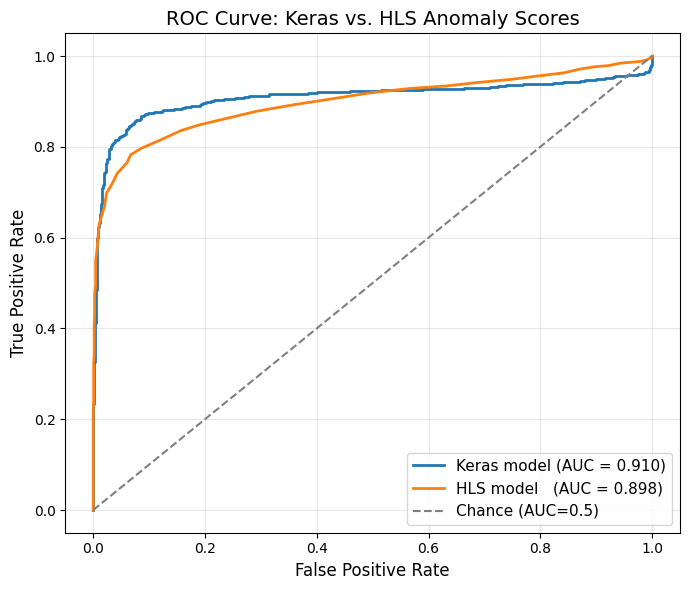

Keras   ROC AUC = 0.9096
HLS     ROC AUC = 0.8982


In [21]:
# 1) Convert y_true into a “1=anomaly, 0=normal” array for ROC/AUC
y_true_anom = (~y_true).astype(int)

# 2) Compute ROC curve + AUC for the Keras model
fpr_keras, tpr_keras, _ = roc_curve(y_true_anom, y_pred_student)
auc_keras = auc(fpr_keras, tpr_keras)

# 3) Compute ROC curve + AUC for the HLS model
fpr_hls, tpr_hls, _ = roc_curve(y_true_anom, y_hls)
auc_hls = auc(fpr_hls, tpr_hls)

# 4) Plot both ROC curves on the same figure
plt.figure(figsize=(7, 6))
plt.plot(fpr_keras, tpr_keras, label=f"Keras model (AUC = {auc_keras:.3f})", lw=2)
plt.plot(fpr_hls,   tpr_hls,   label=f"HLS model   (AUC = {auc_hls:.3f})",   lw=2)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Chance (AUC=0.5)")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve: Keras vs. HLS Anomaly Scores", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5) Print numeric AUCs
print(f"Keras   ROC AUC = {auc_keras:.4f}")
print(f"HLS     ROC AUC = {auc_hls:.4f}")
